In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import numpy as np
import pandas as pd
import ast
import glob
import pickle
import dask
import os
import itertools


#from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score


from multiprocessing import Pool, cpu_count

import dask
import dask.dataframe as dd
from dask.distributed import Client
#client = Client(n_workers=20, memory_limit="10GB", interface='lo')
from concurrent.futures import ThreadPoolExecutor

import dask_ml.cluster as dask_cluster

from pprint import pprint
import os

### Import Individual GRF

In [2]:
# Individual GRFs by cutoff intermediate
def read_csv(file_path):
    return pd.read_csv(file_path)
def merge_dfs(dfs):
    return pd.concat(dfs, ignore_index=True)

intermediate_results_folder_path = "../data/output/intermediate_by_cutoff/"
csv_files = [os.path.join(intermediate_results_folder_path, f) for f in os.listdir(intermediate_results_folder_path) if f.endswith('.csv')]
pool = Pool()
dfs = pool.map(read_csv, csv_files)
merged_individual_grfs_df = merge_dfs(dfs)
merged_individual_grfs_df = merged_individual_grfs_df.sort_values(['days_from_start', 'fips'])
merged_individual_grfs_df.to_csv("../data/output/glob_merged_individual_grfs.csv",index=False)

In [3]:
(merged_individual_grfs_df).head()

,fips,county,state,days_from_start,datetime,log_rolled_cases.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days
1730019,6037,Los Angeles,California,53,2020-03-14,3.347395,780.705984,-0.005777,4.163408,3.083049,3.306957,-119.987116
1730015,6085,Santa Clara,California,53,2020-03-14,4.032976,NaN,-0.016267,NaN,3.741067,3.919108,-42.611200
1730017,25017,Middlesex,Massachusetts,53,2020-03-14,3.692445,NaN,0.011847,NaN,3.547032,3.775376,58.506201
1730018,36059,Nassau,New York,53,2020-03-14,3.534729,NaN,-0.021308,NaN,2.989569,3.385571,-32.529481
1730016,36119,Westchester,New York,53,2020-03-14,4.841935,NaN,-0.012171,NaN,4.613449,4.756738,-56.951041


In [4]:
merged_individual_grfs_df

,fips,county,state,days_from_start,datetime,log_rolled_cases.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days
1730019,6037,Los Angeles,California,53,2020-03-14,3.347395,780.705984,-0.005777,4.163408,3.083049,3.306957,-119.987116
1730015,6085,Santa Clara,California,53,2020-03-14,4.032976,NaN,-0.016267,NaN,3.741067,3.919108,-42.611200
1730017,25017,Middlesex,Massachusetts,53,2020-03-14,3.692445,NaN,0.011847,NaN,3.547032,3.775376,58.506201
1730018,36059,Nassau,New York,53,2020-03-14,3.534729,NaN,-0.021308,NaN,2.989569,3.385571,-32.529481
1730016,36119,Westchester,New York,53,2020-03-14,4.841935,NaN,-0.012171,NaN,4.613449,4.756738,-56.951041
...,...,...,...,...,...,...,...,...,...,...,...,...
1415051,56033,Sheridan,Wyoming,1075,2022-12-31,4.596562,NaN,-0.004131,NaN,4.633086,4.567647,-167.807177
1412917,56037,Sweetwater,Wyoming,1075,2022-12-31,4.326967,NaN,0.003097,NaN,4.405018,4.348649,223.784804
1413746,56039,Teton,Wyoming,1075,2022-12-31,4.313671,NaN,-0.008907,NaN,4.285457,4.251326,-77.824630
1413615,56041,Uinta,Wyoming,1075,2022-12-31,3.681711,NaN,-0.002894,NaN,3.711110,3.661452,-239.504290


### Import TLGRF RMSE and MAE

In [5]:
#TLGRF_RMSE_path = "../data/output/block_mse_windowsize=2.csv" 
#TLGRF_MAE_path = "../data/output/block_mae_windowsize=2.csv"

#TLGRF_RMSE = pd.read_csv(TLGRF_RMSE_path)
#TLGRF_RMSE["block.rmse.last"] = np.sqrt(TLGRF_RMSE["block.mse.last"])
#TLGRF_RMSE = TLGRF_RMSE[["cutoff","block.rmse.last"]]
#TLGRF_RMSE = TLGRF_RMSE.dropna(subset=["block.rmse.last"])

#TLGRF_MAE = pd.read_csv(TLGRF_MAE_path)[["cutoff","block.mae.last"]]
#TLGRF_performance = pd.merge(TLGRF_MAE,TLGRF_RMSE,on="cutoff",how="inner")
#TLGRF_performance["datetime"] = pd.to_datetime("2020-03-14") + pd.to_timedelta(TLGRF_performance["cutoff"], unit="D") - pd.Timedelta(days=53) 
wsize_results_dict = {}
wsize = 2
wsize_results_dict[wsize] = []
print("merged_TLGRF_results_wsize={}.csv does not exist. Creating it".format(wsize))
pattern = "block_results*.csv"
files = glob.glob(os.path.join("../data/output", "backtest_state_forests_windowsize={}".format(wsize),pattern))
# empty list to store dataframes
with ThreadPoolExecutor() as executor:
    results = executor.map(read_csv, files)
    for result in results:
        wsize_results_dict[wsize].append(result)
wsize_results_dict[wsize] = pd.concat(wsize_results_dict[wsize]).sort_values(by=["fips","days_from_start"])


merged_TLGRF_results_wsize=2.csv does not exist. Creating it


In [6]:
TLGRF_backtest = wsize_results_dict[wsize]
def compute_metrics(df, days_from_start_cutoff=1075):
    df["shifted_log_rolled_cases"] = df.groupby("fips")["log_rolled_cases.x"].shift(periods=-7)
    df = df.dropna(subset=["shifted_log_rolled_cases"])
    df = df.loc[df['shifted_log_rolled_cases'] != -np.inf]
    
    TLGRF_results_rmse = df.groupby('days_from_start').apply(lambda x: mean_squared_error(x['shifted_log_rolled_cases'], x['predicted.grf.future.last'], squared=False))
    TLGRF_results_mae = df.groupby('days_from_start').apply(lambda x: mean_absolute_error(x['shifted_log_rolled_cases'], x['predicted.grf.future.last']))

    TLGRF_results_performance = pd.DataFrame()
    TLGRF_results_performance["RMSE"] = TLGRF_results_rmse
    TLGRF_results_performance["MAE"] = TLGRF_results_mae
    #TLGRF_results_performance = pd.merge(TLGRF_results_performance, grf_counts[["days_from_start","date.x"]], on="days_from_start", how="left")
    #TLGRF_results_performance["datetime"] = pd.to_datetime(TLGRF_results_performance["date.x"])

    TLGRF_results_performance = TLGRF_results_performance.reset_index()
    #TLGRF_results_performance = TLGRF_results_performance[TLGRF_results_performance["days_from_start"] <= days_from_start_cutoff]
    TLGRF_results_performance["datetime"] = pd.to_datetime("2020-03-14") + pd.to_timedelta(TLGRF_results_performance["days_from_start"] - 53, unit="D")
    return TLGRF_results_performance
TLGRF_performance = compute_metrics(TLGRF_backtest)
TLGRF_performance

,days_from_start,RMSE,MAE,datetime
0,51,0.774891,0.690326,2020-03-12
1,52,0.874976,0.843891,2020-03-13
2,53,0.768724,0.672062,2020-03-14
3,54,0.785692,0.690295,2020-03-15
4,55,0.833729,0.736912,2020-03-16
...,...,...,...,...
1095,1146,0.324026,0.153327,2023-03-12
1096,1147,0.360667,0.183158,2023-03-13
1097,1148,0.389413,0.191321,2023-03-14
1098,1149,0.351515,0.178457,2023-03-15


In [7]:
TLGRF_performance = TLGRF_performance[(TLGRF_performance["days_from_start"] >= 63) & (TLGRF_performance["days_from_start"] <= 1075)]
TLGRF_performance

,days_from_start,RMSE,MAE,datetime
12,63,0.514756,0.444087,2020-03-24
13,64,0.480018,0.411694,2020-03-25
14,65,0.507372,0.458513,2020-03-26
15,66,0.524547,0.489171,2020-03-27
16,67,0.515482,0.481704,2020-03-28
...,...,...,...,...
1020,1071,0.269481,0.200547,2022-12-27
1021,1072,0.188295,0.131206,2022-12-28
1022,1073,0.176473,0.113230,2022-12-29
1023,1074,0.211307,0.114610,2022-12-30


### Import Historical Data

In [8]:
cases_df_path = "../data/augmented_us-counties_latest.csv"
cases_df = dd.read_csv(cases_df_path, assume_missing=True)
cases_df = cases_df.compute()
cases_df = cases_df.sort_values(["fips","days_from_start"])
cases_df.head()

,fips,date,county,state,cases,deaths,datetime,days_from_start,rolled_cases,LAT,...,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP
23,1001.0,2020-03-30,Autauga,Alabama,7.0,0.0,2020-03-30,69.0,5.142857,32.532237,...,0.0,0.0,0.0,0.0,0.0,0.0,3875.0,7.1,0.9,37301.0
120,1001.0,2020-03-31,Autauga,Alabama,7.0,0.0,2020-03-31,70.0,6.000000,32.532237,...,0.0,0.0,0.0,0.0,0.0,0.0,3875.0,7.1,0.9,37301.0
154,1001.0,2020-04-01,Autauga,Alabama,10.0,0.0,2020-04-01,71.0,6.857143,32.532237,...,0.0,0.0,0.0,0.0,0.0,0.0,3875.0,7.1,0.9,37301.0
585,1001.0,2020-04-02,Autauga,Alabama,10.0,0.0,2020-04-02,72.0,7.428571,32.532237,...,0.0,0.0,0.0,0.0,0.0,0.0,3875.0,7.1,0.9,37301.0
55,1001.0,2020-04-03,Autauga,Alabama,12.0,0.0,2020-04-03,73.0,8.285714,32.532237,...,0.0,0.0,0.0,0.0,0.0,0.0,3875.0,7.1,0.9,37301.0


In [9]:
cases_df["log_rolled_cases"] = np.log(cases_df["rolled_cases"])
cases_df["shifted_log_rolled_cases"] = cases_df.groupby("fips")["log_rolled_cases"].shift(periods=-7)

/home/zwang937/anaconda3/lib/python3.7/site-packages/pandas/core/arraylike.py:364: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/zwang937/anaconda3/lib/python3.7/site-packages/pandas/core/arraylike.py:364: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [10]:
outcome_log_rolled_cases = cases_df[["days_from_start", "fips", "log_rolled_cases", "shifted_log_rolled_cases"]]
outcome_log_rolled_cases.head()

,days_from_start,fips,log_rolled_cases,shifted_log_rolled_cases
23,69.0,1001.0,1.637609,2.371578
120,70.0,1001.0,1.791759,2.436116
154,71.0,1001.0,1.925291,2.460809
585,72.0,1001.0,2.005334,2.542726
55,73.0,1001.0,2.114533,2.597385


In [11]:
individual_grfs_results_df = pd.merge(left=merged_individual_grfs_df, right=outcome_log_rolled_cases, on=["days_from_start","fips"], how="inner")
individual_grfs_results_df = individual_grfs_results_df.dropna(subset=["shifted_log_rolled_cases"])
individual_grfs_results_df = individual_grfs_results_df.loc[individual_grfs_results_df['shifted_log_rolled_cases'] != -np.inf]

individual_grfs_results_df.head()

,fips,county,state,days_from_start,datetime,log_rolled_cases.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days,log_rolled_cases,shifted_log_rolled_cases
0,6037,Los Angeles,California,53,2020-03-14,3.347395,780.705984,-0.005777,4.163408,3.083049,3.306957,-119.987116,3.347395,5.272267
1,6085,Santa Clara,California,53,2020-03-14,4.032976,NaN,-0.016267,NaN,3.741067,3.919108,-42.611200,4.032976,5.156589
2,25017,Middlesex,Massachusetts,53,2020-03-14,3.692445,NaN,0.011847,NaN,3.547032,3.775376,58.506201,3.692445,4.722318
3,36059,Nassau,New York,53,2020-03-14,3.534729,NaN,-0.021308,NaN,2.989569,3.385571,-32.529481,3.534729,6.023448
4,36119,Westchester,New York,53,2020-03-14,4.841935,NaN,-0.012171,NaN,4.613449,4.756738,-56.951041,4.841935,6.488988


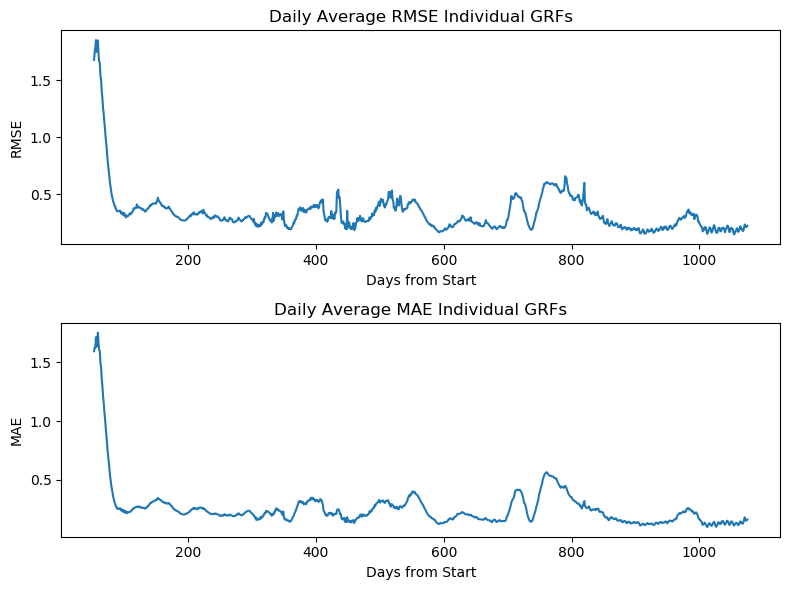

In [12]:
individual_grfs_rmse = individual_grfs_results_df.groupby('days_from_start').apply(lambda x: mean_squared_error(x['shifted_log_rolled_cases'], x['predicted.grf.future.last'], squared=False))
individual_grfs_mae = individual_grfs_results_df.groupby('days_from_start').apply(lambda x: mean_absolute_error(x['shifted_log_rolled_cases'], x['predicted.grf.future.last']))

individual_grfs_performance = pd.DataFrame()
individual_grfs_performance["RMSE"] = individual_grfs_rmse
individual_grfs_performance["MAE"] = individual_grfs_mae
individual_grfs_performance = individual_grfs_performance.reset_index()
individual_grfs_performance = pd.merge(individual_grfs_performance, individual_grfs_results_df[["days_from_start","datetime"]], on=["days_from_start"], how="left")
individual_grfs_performance["datetime"] = pd.to_datetime(individual_grfs_performance["datetime"])
individual_grfs_performance

# Plot the daily average RMSE and MAE in separate graphs
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))
individual_grfs_rmse.plot(ax=ax1)
ax1.set(title='Daily Average RMSE Individual GRFs', xlabel='Days from Start', ylabel='RMSE')
individual_grfs_mae.plot(ax=ax2)
ax2.set(title='Daily Average MAE Individual GRFs', xlabel='Days from Start', ylabel='MAE')
plt.tight_layout()
plt.show()


In [13]:
individual_grfs_performance = individual_grfs_performance[individual_grfs_performance["days_from_start"] >= 63]
individual_grfs_performance

,days_from_start,RMSE,MAE,datetime
376,63,1.538733,1.489290,2020-03-24
377,63,1.538733,1.489290,2020-03-24
378,63,1.538733,1.489290,2020-03-24
379,63,1.538733,1.489290,2020-03-24
380,63,1.538733,1.489290,2020-03-24
...,...,...,...,...
1942729,1075,0.223598,0.163963,2022-12-31
1942730,1075,0.223598,0.163963,2022-12-31
1942731,1075,0.223598,0.163963,2022-12-31
1942732,1075,0.223598,0.163963,2022-12-31


/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `ob

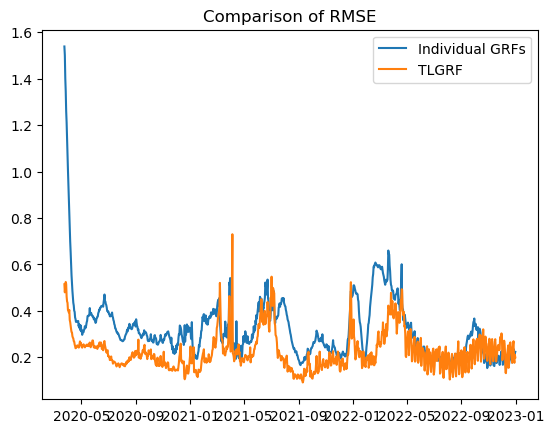

In [14]:
plt.plot(individual_grfs_performance["datetime"], individual_grfs_performance['RMSE'], label='Individual GRFs')
plt.plot(TLGRF_performance['datetime'],TLGRF_performance['RMSE'], label='TLGRF')

# Set plot title and legend
plt.title('Comparison of RMSE')
plt.legend()

# Show the plot
plt.show()

/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]
/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing

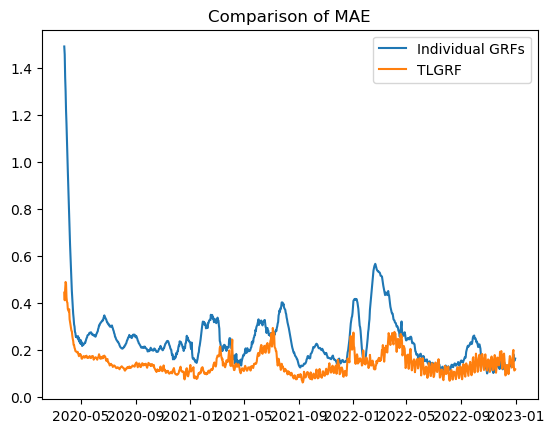

In [15]:
plt.plot(individual_grfs_performance["datetime"], individual_grfs_performance['MAE'], label='Individual GRFs')
plt.plot(TLGRF_performance["datetime"],TLGRF_performance['MAE'], label='TLGRF')

# Set plot title and legend
plt.title('Comparison of MAE')
plt.legend()

# Show the plot
plt.show()

In [16]:
tlgrf_median_rmse = TLGRF_performance['RMSE'].median()
tlgrf_median_mae = TLGRF_performance['MAE'].median()

# Calculate median RMSE and MAE for individual GRFs
ind_grfs_median_rmse = individual_grfs_performance['RMSE'].median()
ind_grfs_median_mae = individual_grfs_performance['MAE'].median()

# Create a summary statistics table
summary_table = pd.DataFrame({
    'Median RMSE': [ind_grfs_median_rmse, tlgrf_median_rmse],
    'Median MAE': [ind_grfs_median_mae, tlgrf_median_mae]
}, index=['Individual GRFs', 'TLGRF'])
summary_table

,Median RMSE,Median MAE
Individual GRFs,0.277002,0.207693
TLGRF,0.209159,0.132354


### Tabulate How Many Missing Results Per Day

In [17]:
n_fips = len(cases_df["fips"].unique())
n_fips

3143

In [18]:
TLGRF_results_path = "../data/output/merged_TLGRF_results.csv"
TLGRF_results_df = dd.read_csv(TLGRF_results_path, assume_missing=True).compute()
TLGRF_results_df = TLGRF_results_df.sort_values(["fips","days_from_start"])
TLGRF_results_df.head()

,fips,county,state,date.x,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,...,block new cases,block.mse.0,block.mse.last,block.mae,block.mae.0,block.mae.last,block.mape,block.mape.0,block.mape.last,log_rolled_cases.x
31152,1001.0,Autauga,Alabama,2020-04-17,9.0,87.0,3.030824,-31.594470,0.026873,3.375100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
86180,1001.0,Autauga,Alabama,2020-04-18,6.0,88.0,3.030824,-216.661701,0.010264,3.199023,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15414,1001.0,Autauga,Alabama,2020-04-19,8.0,89.0,3.044522,-79.225633,0.018760,3.287171,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
121038,1001.0,Autauga,Alabama,2020-04-20,9.0,90.0,3.064725,-60.758373,0.021026,3.317038,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
151299,1001.0,Autauga,Alabama,2020-04-21,7.0,91.0,3.064725,-159.259411,0.012541,3.226170,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
TLGRF_counts = TLGRF_results_df.groupby('days_from_start')["tau.hat"].count()
TLGRF_counts

days_from_start
51.0         5
52.0         6
53.0         8
54.0        10
55.0        14
          ... 
1071.0    2676
1072.0    2674
1073.0    2667
1074.0    2664
1075.0    2658
Name: tau.hat, Length: 1025, dtype: int64

In [20]:
individual_grfs_counts = merged_individual_grfs_df.groupby('days_from_start')["tau.hat"].count()
individual_grfs_counts

days_from_start
53         7
54         9
55        13
56        17
57        24
        ... 
1071    2672
1072    2670
1073    2663
1074    2661
1075    2655
Name: tau.hat, Length: 1023, dtype: int64

In [21]:
all_dates = pd.date_range(start='2020-03-19', end='2022-12-31')
all_dates_list = all_dates.to_pydatetime().tolist()

len(all_dates_list)

1018

In [22]:
grf_counts = pd.DataFrame()
grf_counts["TLGRF_counts"] = TLGRF_counts
grf_counts["individual_grfs_counts"] = individual_grfs_counts
grf_counts["total"] = n_fips
grf_counts = grf_counts.reset_index()

grf_counts = pd.merge(grf_counts, TLGRF_results_df[["days_from_start","date.x"]], on=["days_from_start"], how="left").drop_duplicates()
grf_counts['date.x'] = pd.to_datetime(grf_counts['date.x'])

grf_counts["individual_grfs_counts"] = grf_counts["individual_grfs_counts"].fillna(0)
grf_counts

,days_from_start,TLGRF_counts,individual_grfs_counts,total,date.x
0,51.0,5,0.0,3143,2020-03-12
5,52.0,6,0.0,3143,2020-03-13
11,53.0,8,7.0,3143,2020-03-14
19,54.0,10,9.0,3143,2020-03-15
29,55.0,14,13.0,3143,2020-03-16
...,...,...,...,...,...
2423474,1071.0,2676,2672.0,3143,2022-12-27
2426150,1072.0,2674,2670.0,3143,2022-12-28
2428824,1073.0,2667,2663.0,3143,2022-12-29
2431491,1074.0,2664,2661.0,3143,2022-12-30


In [23]:
grf_counts['date.x'].iloc[-1]

Timestamp('2022-12-31 00:00:00')

/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `ob

<Figure size 640x480 with 0 Axes>

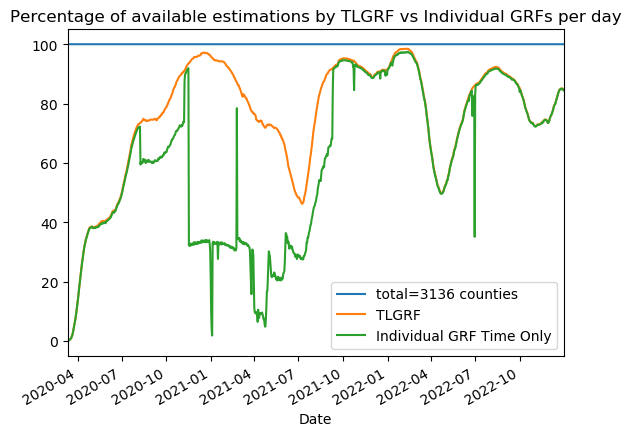

In [24]:
plt.clf()
fig, ax = plt.subplots()

ax.plot(grf_counts["date.x"], grf_counts['total']/n_fips * 100, label='total={} counties'.format(min(n_fips, 3136)))
ax.plot(grf_counts["date.x"],grf_counts['TLGRF_counts']/ n_fips * 100, label='TLGRF')
ax.plot(grf_counts["date.x"], grf_counts['individual_grfs_counts']/ n_fips * 100, label='Individual GRF Time Only')


# Set plot title and legend
ax.set_title('Percentage of available estimations by TLGRF vs Individual GRFs per day')
ax.set_xlabel("Date")
# Set x-axis limits using minimum and maximum dates
ax.set_xlim(left=grf_counts['date.x'].min(), right=grf_counts['date.x'].max())

# Set major locator and formatter for x-axis
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
#ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()

# Set rotation for x-axis tick labels to prevent overlapping
#plt.xticks(rotation=45)

#plt.gcf().autofmt_xdate()

# Rotate and format the date labels
#fig.autofmt_xdate()


plt.legend()

# Show the plot
plt.show()

In [25]:
np.sum(grf_counts["individual_grfs_counts"])

1944282.0

In [26]:
n_fips * (1075-51)

3218432

In [27]:
np.sum(grf_counts["TLGRF_counts"])

2436813

In [28]:
merged_TLGRF_results_df = pd.merge(TLGRF_results_df, cases_df, on=["days_from_start","fips"], how="inner")
merged_TLGRF_results_df["shifted_log_rolled_cases"] = merged_TLGRF_results_df.groupby("fips")["log_rolled_cases"].shift(periods=-7)
merged_TLGRF_results_df = merged_TLGRF_results_df.dropna(subset=["shifted_log_rolled_cases"])
merged_TLGRF_results_df = merged_TLGRF_results_df.loc[merged_TLGRF_results_df['shifted_log_rolled_cases'] != -np.inf]
merged_TLGRF_results_df.to_csv("../data/output/merged_TLGRF_results_df.csv", index=False)

TLGRF_results_rmse = merged_TLGRF_results_df.groupby('days_from_start').apply(lambda x: mean_squared_error(x['shifted_log_rolled_cases'], x['predicted.grf.future.last'], squared=False))
TLGRF_results_mae = merged_TLGRF_results_df.groupby('days_from_start').apply(lambda x: mean_absolute_error(x['shifted_log_rolled_cases'], x['predicted.grf.future.last']))

TLGRF_results_performance = pd.DataFrame()
TLGRF_results_performance["RMSE"] = TLGRF_results_rmse
TLGRF_results_performance["MAE"] = TLGRF_results_mae

TLGRF_results_performance = pd.merge(TLGRF_results_performance, grf_counts[["days_from_start","date.x"]], on="days_from_start", how="left")
TLGRF_results_performance["datetime"] = pd.to_datetime(TLGRF_results_performance["date.x"])

TLGRF_results_performance = TLGRF_results_performance.reset_index()


TLGRF_results_performance

,index,days_from_start,RMSE,MAE,date.x,datetime
0,0,51.0,0.781642,0.709696,2020-03-12,2020-03-12
1,1,52.0,0.846487,0.802498,2020-03-13,2020-03-13
2,2,53.0,0.791903,0.706543,2020-03-14,2020-03-14
3,3,54.0,0.791635,0.690295,2020-03-15,2020-03-15
4,4,55.0,0.828698,0.755220,2020-03-16,2020-03-16
...,...,...,...,...,...,...
1013,1013,1064.0,0.260425,0.166655,2022-12-20,2022-12-20
1014,1014,1065.0,0.224934,0.146908,2022-12-21,2022-12-21
1015,1015,1066.0,0.230064,0.146450,2022-12-22,2022-12-22
1016,1016,1067.0,0.177578,0.122008,2022-12-23,2022-12-23


In [29]:
merged_TLGRF_results_df

,fips,county_x,state_x,date.x,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,...,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,log_rolled_cases,shifted_log_rolled_cases
0,1001.0,Autauga,Alabama,2020-04-17,9.0,87.0,3.030824,-31.594470,0.026873,3.375100,...,0.0,0.0,0.0,0.0,3875.0,7.1,0.9,37301.0,3.030824,3.122994
1,1001.0,Autauga,Alabama,2020-04-18,6.0,88.0,3.030824,-216.661701,0.010264,3.199023,...,0.0,0.0,0.0,0.0,3875.0,7.1,0.9,37301.0,3.030824,3.160035
2,1001.0,Autauga,Alabama,2020-04-19,8.0,89.0,3.044522,-79.225633,0.018760,3.287171,...,0.0,0.0,0.0,0.0,3875.0,7.1,0.9,37301.0,3.044522,3.183989
3,1001.0,Autauga,Alabama,2020-04-20,9.0,90.0,3.064725,-60.758373,0.021026,3.317038,...,0.0,0.0,0.0,0.0,3875.0,7.1,0.9,37301.0,3.064725,3.213145
4,1001.0,Autauga,Alabama,2020-04-21,7.0,91.0,3.064725,-159.259411,0.012541,3.226170,...,0.0,0.0,0.0,0.0,3875.0,7.1,0.9,37301.0,3.064725,3.241476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2436801,99999.0,New York City,New York,2022-12-20,26563.0,1064.0,11.325935,481.689533,0.019618,11.561356,...,1.0,0.0,3.0,5.0,136920.0,8.2,0.2,1164366.0,11.325935,11.308842
2436802,99999.0,New York City,New York,2022-12-21,26936.0,1065.0,11.341732,401.366884,0.017220,11.548373,...,1.0,0.0,3.0,5.0,136920.0,8.2,0.2,1164366.0,11.341732,11.300346
2436803,99999.0,New York City,New York,2022-12-22,26968.0,1066.0,11.354044,301.450246,0.014948,11.533424,...,1.0,0.0,3.0,5.0,136920.0,8.2,0.2,1164366.0,11.354044,11.290173
2436804,99999.0,New York City,New York,2022-12-23,26795.0,1067.0,11.356125,-189.582066,0.009073,11.465006,...,1.0,0.0,3.0,5.0,136920.0,8.2,0.2,1164366.0,11.356125,11.281184


/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `ob

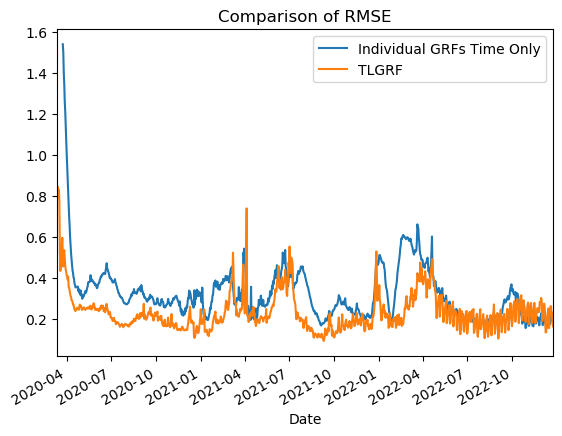

In [30]:
fig, ax = plt.subplots()

ax.plot(individual_grfs_performance["datetime"], individual_grfs_performance['RMSE'], label='Individual GRFs Time Only')
ax.plot(TLGRF_results_performance["datetime"], TLGRF_results_performance['RMSE'], label='TLGRF')

# Set plot title and legend
#ax.set_title('RMSE comparison TLGRF vs Individual GRFs per day')
ax.set_xlabel("Date")
# Set x-axis limits using minimum and maximum dates
ax.set_xlim(left=TLGRF_results_performance['datetime'].min(), right=TLGRF_results_performance['datetime'].max())

# Set major locator and formatter for x-axis
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
#ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()


# Set plot title and legend
plt.title('Comparison of RMSE')
plt.legend()

# Show the plot
plt.show()

/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]
/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing

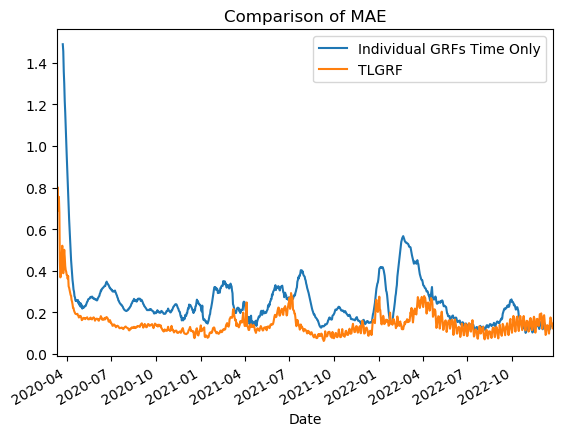

In [31]:
fig, ax = plt.subplots()

ax.plot(individual_grfs_performance["datetime"], individual_grfs_performance['MAE'], label='Individual GRFs Time Only')
ax.plot(TLGRF_results_performance["datetime"], TLGRF_results_performance['MAE'], label='TLGRF')

# Set plot title and legend
ax.set_title('MAE comparison TLGRF vs Individual GRFs per day')
ax.set_xlabel("Date")
# Set x-axis limits using minimum and maximum dates
ax.set_xlim(left=TLGRF_results_performance['datetime'].min(), right=TLGRF_results_performance['datetime'].max())

# Set major locator and formatter for x-axis
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
#ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()


# Set plot title and legend
plt.title('Comparison of MAE')
plt.legend()

# Show the plot
plt.show()

In [32]:
merged_results = pd.merge(individual_grfs_performance, TLGRF_results_performance, on="days_from_start", how="right", suffixes=("_individual","_TLGRF")).drop_duplicates()

In [33]:
merged_results

,days_from_start,RMSE_individual,MAE_individual,datetime_individual,index,RMSE_TLGRF,MAE_TLGRF,date.x,datetime_TLGRF
0,51.0,NaN,NaN,NaT,0,0.781642,0.709696,2020-03-12,2020-03-12
1,52.0,NaN,NaN,NaT,1,0.846487,0.802498,2020-03-13,2020-03-13
2,53.0,NaN,NaN,NaT,2,0.791903,0.706543,2020-03-14,2020-03-14
3,54.0,NaN,NaN,NaT,3,0.791635,0.690295,2020-03-15,2020-03-15
4,55.0,NaN,NaN,NaT,4,0.828698,0.755220,2020-03-16,2020-03-16
...,...,...,...,...,...,...,...,...,...
1910467,1064.0,0.221306,0.148108,2022-12-20,1013,0.260425,0.166655,2022-12-20,2022-12-20
1913096,1065.0,0.193966,0.138609,2022-12-21,1014,0.224934,0.146908,2022-12-21,2022-12-21
1915737,1066.0,0.199870,0.139072,2022-12-22,1015,0.230064,0.146450,2022-12-22,2022-12-22
1918394,1067.0,0.190459,0.131041,2022-12-23,1016,0.177578,0.122008,2022-12-23,2022-12-23


In [34]:
later_merged_results = merged_results[merged_results["MAE_TLGRF"] >= merged_results["MAE_individual"]]
later_merged_results = later_merged_results.sort_values(by=["days_from_start"], ascending=True)
later_merged_results.tail(20)

,days_from_start,RMSE_individual,MAE_individual,datetime_individual,index,RMSE_TLGRF,MAE_TLGRF,date.x,datetime_TLGRF
1849662,1039.0,0.188104,0.128869,2022-11-25,988,0.231261,0.134280,2022-11-25,2022-11-25
1851997,1040.0,0.167357,0.119373,2022-11-26,989,0.237043,0.153353,2022-11-26,2022-11-26
1854329,1041.0,0.186997,0.131918,2022-11-27,990,0.281859,0.190425,2022-11-27,2022-11-27
1856648,1042.0,0.199087,0.140200,2022-11-28,991,0.275237,0.191287,2022-11-28,2022-11-28
1858955,1043.0,0.214037,0.151436,2022-11-29,992,0.275238,0.188802,2022-11-29,2022-11-29
1861264,1044.0,0.226685,0.153728,2022-11-30,993,0.300839,0.194633,2022-11-30,2022-11-30
1863580,1045.0,0.219578,0.142515,2022-12-01,994,0.282267,0.147226,2022-12-01,2022-12-01
1868265,1047.0,0.167947,0.118145,2022-12-03,996,0.197740,0.140926,2022-12-03,2022-12-03
1870636,1048.0,0.175125,0.125452,2022-12-04,997,0.228963,0.168625,2022-12-04,2022-12-04
1873018,1049.0,0.199749,0.138549,2022-12-05,998,0.256820,0.182790,2022-12-05,2022-12-05


/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/home/zwang937/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `ob

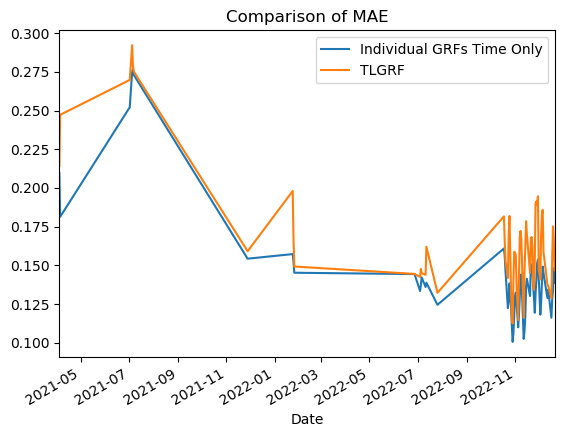

In [35]:
fig, ax = plt.subplots()

ax.plot(later_merged_results["datetime_individual"], later_merged_results['MAE_individual'], label='Individual GRFs Time Only')
ax.plot(later_merged_results["datetime_TLGRF"], later_merged_results['MAE_TLGRF'], label='TLGRF')

# Set plot title and legend
ax.set_title('MAE comparison TLGRF vs Individual GRFs per day')
ax.set_xlabel("Date")
# Set x-axis limits using minimum and maximum dates
ax.set_xlim(left=later_merged_results['datetime_individual'].min(), right=later_merged_results['datetime_individual'].max())

# Set major locator and formatter for x-axis
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
#ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()


# Set plot title and legend
plt.title('Comparison of MAE')
plt.legend()

# Show the plot
plt.show()